# Experiments Notebooks

In [48]:
import pickle
import numpy as np

In [49]:
with open('/home/kojogyaase/Projects/Research/carla-rl/evidence/uncertainty_profile_at_junctions.pickle', 'rb') as handle:
    dataset=pickle.load(handle)

In [50]:
# dataset.keys()
log_stds=np.array(dataset["log_stds"])
junctions=np.array(dataset["junctions"])

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# plt.rcParams['text.usetex'] = True
# Set the style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("paper", font_scale=1.2)

# Create the figure with a specific size and DPI
plt.figure(figsize=(12, 6), dpi=300)

# Plot with enhanced styling
# Standard deviations (dotted lines)
plt.plot(np.array(log_stds)[:,0], color='royalblue', linestyle=':', alpha=0.6, 
         label='Steering', linewidth=1.5)
plt.plot(np.array(log_stds)[:,1], color='crimson', linestyle=':', alpha=0.6, 
         label='Throttle', linewidth=1.5)


# Add vertical lines for junctions and restarts
for k in junctions:
    plt.axvline(x=k, color='forestgreen', ls='--', alpha=0.5, linewidth=1.5,
                label='Junction' if k == junctions[0] else '')


# Customize the plot
plt.xlabel('Time Steps', fontsize=12, fontweight='bold')
plt.ylabel('Log of Stddev', fontsize=12, fontweight='bold')
plt.title('Uncertainty Profile at Junctions', fontsize=14, fontweight='bold', pad=20)

# Enhance the legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,
          frameon=True, fancybox=True, shadow=True)

# Adjust layout to prevent legend cutoff
# plt.tight_layout()

# Save with high quality
plt.savefig("uncertainty_profile_at_junctions.pdf", dpi=300, bbox_inches='tight',
            format='pdf', facecolor='white', edgecolor='none')

# Optional: save also as PNG for quick viewing
# plt.savefig("uncertainty_profile_at_junctions.png", dpi=300, bbox_inches='tight',
            # format='png', facecolor='white', edgecolor='none')

plt.close()

In [52]:
with open('/home/kojogyaase/Projects/Research/carla-rl/nomad_results.pkl', 'rb') as handle:
    dataset=pickle.load(handle)

In [53]:
# dataset

In [54]:
data_keys=dataset.keys()

In [55]:
success_rate=[]
skip_frame=[]
for k  in data_keys:
    if k != "experiment_results":
        success_rate.append(np.mean(dataset[k]))
        skip_frame.append(int(k)-1)


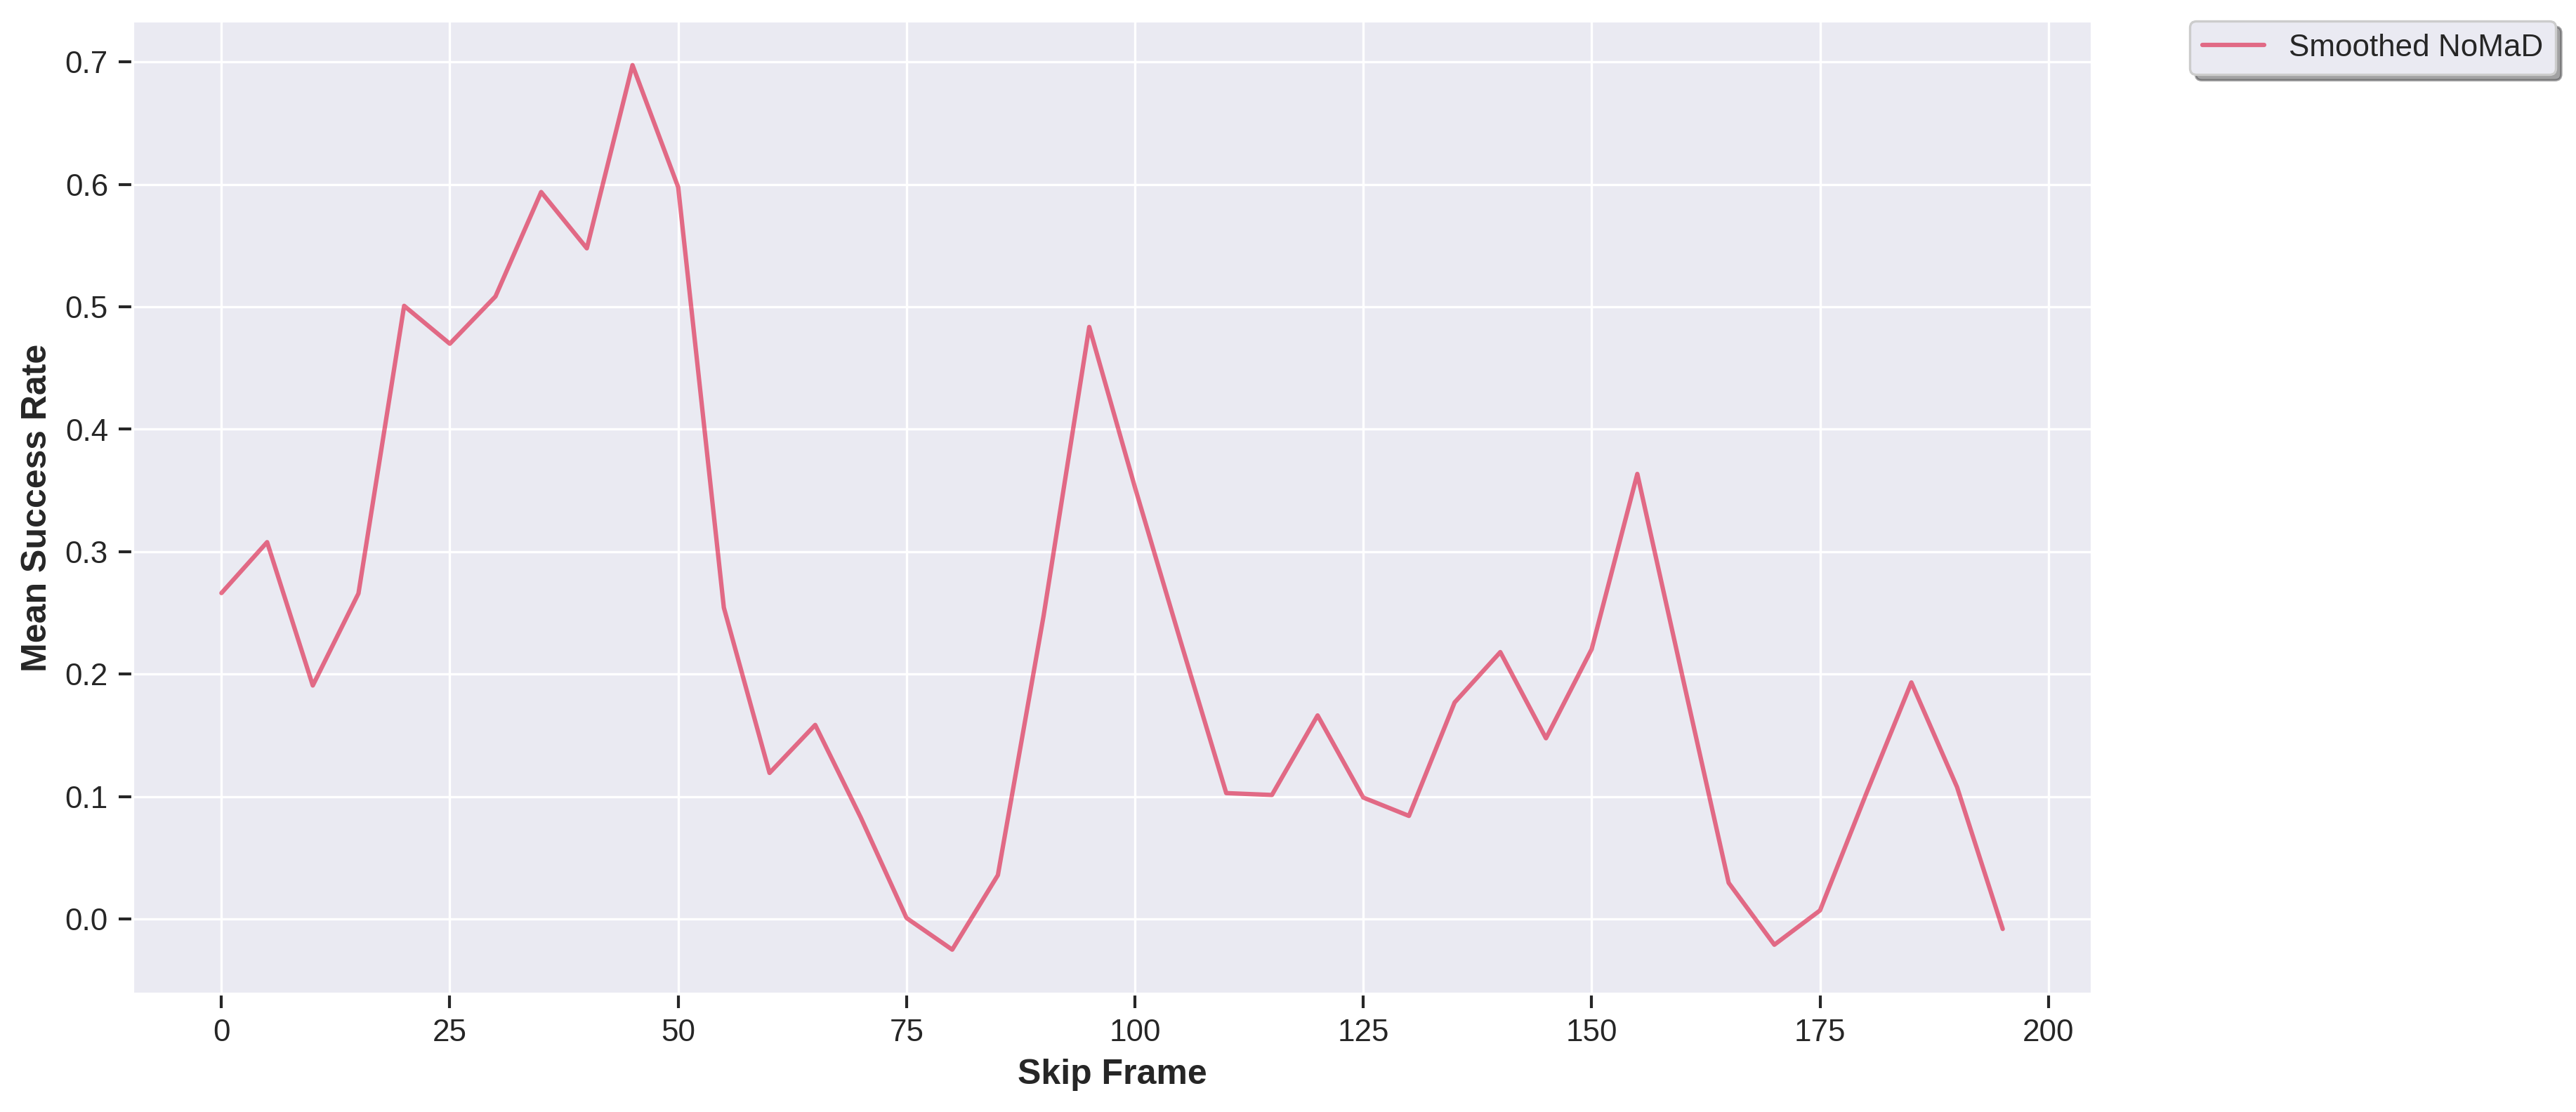

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_smoothing_spline


# x_range = np.arange(x_min, x_max, some_step)
# plt.plot(x_range, cs(x_range), label='Cubic Spline')
# plt.rcParams['text.usetex'] = True
# Set the style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("paper", font_scale=1.2)

# Create the figure with a specific size and DPI
plt.figure(figsize=(12, 6), dpi=300)


# Plot with enhanced styling
# Standard deviations (dotted lines)
x=np.array(skip_frame)
y=np.array(success_rate)
cs = make_smoothing_spline(x,y)
# plt.plot(x,y, color='royalblue', alpha=0.6, 
#          label='NoMaD', linewidth=1.5)
plt.plot(x,cs(x), color='crimson', alpha=0.6, 
         label='NoMaD', linewidth=1.5)
# plt.plot(np.array(log_stds)[:,1], color='crimson', linestyle=':', alpha=0.6, 
#          label='Throttle', linewidth=1.5)

# Add vertical lines for junctions and restarts
# for k in junctions:
#     plt.axvline(x=k, color='forestgreen', ls='--', alpha=0.5, linewidth=1.5,
#                 label='Junction' if k == junctions[0] else '')


# Customize the plot
plt.xlabel('Skip Frame', fontsize=12, fontweight='bold')
plt.ylabel('Mean Success Rate', fontsize=12, fontweight='bold')
# plt.title('Uncertainty Profile at Junctions', fontsize=14, fontweight='bold', pad=20)

# Enhance the legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,
          frameon=True, fancybox=True, shadow=True)

# Adjust layout to prevent legend cutoff
# plt.tight_layout()

# Save with high quality
plt.savefig("success_rate.pdf", dpi=300, bbox_inches='tight',
            format='pdf', facecolor='white', edgecolor='none')

# Optional: save also as PNG for quick viewing
# plt.savefig("uncertainty_profile_at_junctions.png", dpi=300, bbox_inches='tight',
            # format='png', facecolor='white', edgecolor='none')
plt.show()
plt.close()